# Notebook 06 — Supervision MQTT temps réel (Phase 7)

**Objectif :** Analyser le comportement du superviseur Phase 7 (Option E — consumer MQTT) comparé au superviseur Phase 6 (polling REST).

Ce notebook couvre :
1. Vérification de la connectivité MQTT et de l'alimentation du buffer
2. Visualisation des features glissantes calculées par `OnlineFeatureBuffer`
3. Analyse des décisions prises (risk_score, RPM commandé)
4. Comparaison du comportement à différentes vitesses de simulation
5. Chargement et analyse des logs de décision JSONL

**Prérequis :** jumeaux-chauds doit tourner (`docker compose up -d` dans le dossier jumeaux-chauds).

## 0. Imports et configuration

In [1]:
import sys
import os
import json
import time
import asyncio
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Ajouter la racine du projet au path
ROOT = Path(".").resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Charger les variables d'environnement
from dotenv import load_dotenv
load_dotenv(ROOT / ".env", override=False)

API_URL       = os.getenv("API_BASE_URL", "http://localhost:8000")
MQTT_HOST     = os.getenv("MQTT_BROKER_HOST", "localhost")
MQTT_PORT     = int(os.getenv("MQTT_BROKER_PORT", "1883"))
CLUSTER_ID    = os.getenv("CLUSTER_ID", "cluster_alpha")
LOG_DIR       = ROOT / "supervisor" / "logs"

print(f"API        : {API_URL}")
print(f"MQTT       : {MQTT_HOST}:{MQTT_PORT}")
print(f"Cluster    : {CLUSTER_ID}")
print(f"Logs dir   : {LOG_DIR}")

sns.set_theme(style="darkgrid", palette="muted")
%matplotlib inline

API        : http://localhost:8000
MQTT       : localhost:1883
Cluster    : cluster_alpha
Logs dir   : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs\supervisor\logs


## 1. Vérification de la connectivité

### 1.1 API REST jumeaux-chauds

In [2]:
import httpx

try:
    r = httpx.get(f"{API_URL}/cluster/status", timeout=3.0)
    cluster = r.json()
    machines = cluster.get("machines", {})
    if isinstance(machines, list):
        n_machines = len(machines)
        machine_ids = [m.get("machine_id", m.get("id", f"m{i}")) for i, m in enumerate(machines)]
    else:
        n_machines = len(machines)
        machine_ids = list(machines.keys())
    print(f"✅ API accessible — {n_machines} machines : {machine_ids}")
    speed = cluster.get("speed_multiplier", cluster.get("simulation", {}).get("speed_multiplier", "?"))
    print(f"   Vitesse simulation : {speed}x")
except Exception as e:
    print(f"❌ API inaccessible : {e}")
    print("   Lancez jumeaux-chauds avant de continuer.")

✅ API accessible — 5 machines : ['srv-master-01', 'srv-master-02', 'srv-worker-01', 'srv-worker-02', 'srv-worker-03']
   Vitesse simulation : ?x


### 1.2 Broker MQTT

In [3]:
import socket

try:
    sock = socket.create_connection((MQTT_HOST, MQTT_PORT), timeout=2)
    sock.close()
    print(f"✅ MQTT accessible à {MQTT_HOST}:{MQTT_PORT}")
except Exception as e:
    print(f"❌ MQTT inaccessible : {e}")
    print("   Le superviseur fonctionnera en mode REST fallback.")

✅ MQTT accessible à localhost:1883


## 2. Validation du OnlineFeatureBuffer en direct

On collecte N messages MQTT et on vérifie que les features glissantes évoluent correctement.

In [4]:
from supervisor.online_features import OnlineFeatureBuffer
from supervisor.mqtt_telemetry import MqttTelemetryConsumer

# Paramètres de collecte
COLLECT_TICKS  = 80   # ticks à collecter (>70 pour remplir la fenêtre)
MACHINE_TARGET = None  # None = première machine vue

buf = OnlineFeatureBuffer()
history: list[dict] = []   # snapshots bruts pour visualisation
feat_history: list[dict] = []  # features calculées tick par tick

print(f"Collecte de {COLLECT_TICKS} ticks MQTT...")

Collecte de 80 ticks MQTT...


In [5]:
async def collect_ticks(n_ticks: int):
    """Collecte n_ticks messages MQTT et alimente le buffer."""
    global MACHINE_TARGET
    try:
        import aiomqtt
    except ImportError:
        print("aiomqtt non installé — pip install aiomqtt")
        return

    consumer = MqttTelemetryConsumer(
        buf,
        cluster_id=CLUSTER_ID,
        broker_host=MQTT_HOST,
        broker_port=MQTT_PORT,
    )

    topic = f"dt/{CLUSTER_ID}/+/telemetry"
    count = 0

    try:
        async with aiomqtt.Client(hostname=MQTT_HOST, port=MQTT_PORT) as client:
            await client.subscribe(topic, qos=0)
            print(f"Abonné à {topic}")
            async for message in client.messages:
                payload = json.loads(bytes(message.payload))
                parts   = str(message.topic).split("/")
                machine_id = parts[2] if len(parts) >= 4 else "unknown"

                if MACHINE_TARGET is None:
                    MACHINE_TARGET = machine_id
                    print(f"Machine cible : {machine_id}")

                if machine_id != MACHINE_TARGET:
                    continue

                snap = consumer._normalize(machine_id, payload)
                if snap:
                    buf.update(machine_id, snap)
                    history.append(snap)
                    feat = buf.get_features(machine_id)
                    if feat is not None:
                        feat_history.append(feat.to_dict())

                count += 1
                if count % 10 == 0:
                    print(f"  {count}/{n_ticks} ticks")
                if count >= n_ticks:
                    break
    except Exception as e:
        print(f"Erreur MQTT : {e}")

    return count

# Lancer la collecte
n = await collect_ticks(COLLECT_TICKS)
print(f"\n{n} ticks collectés pour la machine '{MACHINE_TARGET}'")
print(f"Buffer machines : {buf.machines()}")

Abonné à dt/cluster_alpha/+/telemetry
Machine cible : srv-worker-03
  10/80 ticks
  20/80 ticks
  30/80 ticks
  40/80 ticks
  50/80 ticks
  60/80 ticks
  70/80 ticks
  80/80 ticks

80 ticks collectés pour la machine 'srv-worker-03'
Buffer machines : ['srv-worker-03']


### 2.1 Vérification des features glissantes

In [6]:
if not feat_history:
    print("Pas de features collectées — vérifier la connexion MQTT.")
else:
    df_feat = pd.DataFrame(feat_history)
    df_feat.index.name = "tick"

    print(f"Features disponibles : {len(df_feat.columns)} colonnes, {len(df_feat)} ticks")
    print("\nStats sur les features temporelles clés :")
    cols_check = [
        "temperature_c", "temp_delta_5s", "temp_delta_15s", "temp_delta_30s",
        "temp_rolling_mean_30s", "margin_to_shutdown",
        "rpm_rolling_mean_30s", "power_fans_w", "risk_score",
    ]
    cols_present = [c for c in cols_check if c in df_feat.columns]
    display(df_feat[cols_present].describe().round(3))

Features disponibles : 51 colonnes, 80 ticks

Stats sur les features temporelles clés :


,temperature_c,temp_delta_5s,temp_delta_15s,temp_delta_30s,temp_rolling_mean_30s,margin_to_shutdown,rpm_rolling_mean_30s,power_fans_w
count,80.000,80.000,80.000,80.000,80.000,80.000,80.0,80.000
mean,39.884,-0.002,-0.005,-0.007,39.888,48.116,4500.0,17.496
std,0.009,0.001,0.002,0.006,0.008,0.009,0.0,0.000
min,39.870,-0.003,-0.007,-0.012,39.875,48.101,4500.0,17.496
25%,39.877,-0.002,-0.006,-0.011,39.882,48.109,4500.0,17.496
50%,39.884,-0.002,-0.005,-0.011,39.889,48.116,4500.0,17.496
75%,39.891,-0.002,-0.005,0.000,39.895,48.123,4500.0,17.496
max,39.899,0.000,0.000,0.000,39.899,48.130,4500.0,17.496


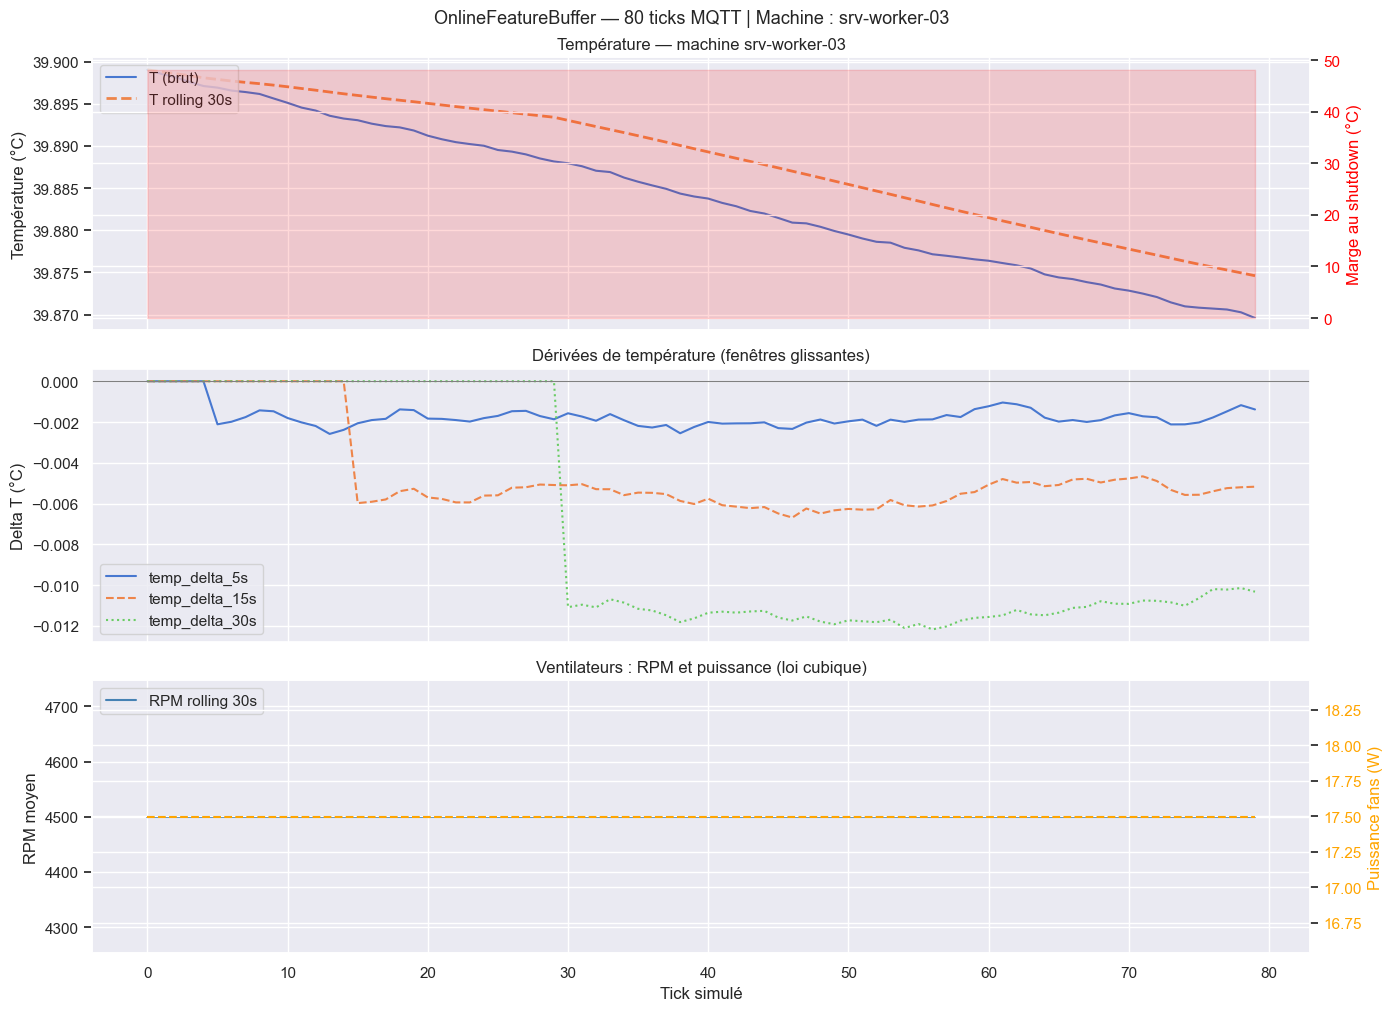

In [7]:
if feat_history:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Température et features glissantes
    ax = axes[0]
    if "temperature_c" in df_feat.columns:
        ax.plot(df_feat.index, df_feat["temperature_c"], label="T (brut)", lw=1.5)
    if "temp_rolling_mean_30s" in df_feat.columns:
        ax.plot(df_feat.index, df_feat["temp_rolling_mean_30s"], label="T rolling 30s", lw=2, ls="--")
    if "margin_to_shutdown" in df_feat.columns:
        ax2 = ax.twinx()
        ax2.fill_between(df_feat.index, df_feat["margin_to_shutdown"], alpha=0.15, color="red", label="Marge shutdown")
        ax2.set_ylabel("Marge au shutdown (°C)", color="red")
        ax2.tick_params(axis='y', labelcolor='red')
    ax.set_ylabel("Température (°C)")
    ax.legend(loc="upper left")
    ax.set_title(f"Température — machine {MACHINE_TARGET}")

    # Deltas de température
    ax = axes[1]
    for col, ls in [("temp_delta_5s", "-"), ("temp_delta_15s", "--"), ("temp_delta_30s", ":")]:
        if col in df_feat.columns:
            ax.plot(df_feat.index, df_feat[col], label=col, ls=ls)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_ylabel("Delta T (°C)")
    ax.legend()
    ax.set_title("Dérivées de température (fenêtres glissantes)")

    # RPM et puissance fans
    ax = axes[2]
    if "rpm_rolling_mean_30s" in df_feat.columns:
        ax.plot(df_feat.index, df_feat["rpm_rolling_mean_30s"], label="RPM rolling 30s", color="steelblue")
    if "power_fans_w" in df_feat.columns:
        ax3 = ax.twinx()
        ax3.plot(df_feat.index, df_feat["power_fans_w"], label="Puissance fans (W)", color="orange", ls="--")
        ax3.set_ylabel("Puissance fans (W)", color="orange")
        ax3.tick_params(axis='y', labelcolor='orange')
    ax.set_ylabel("RPM moyen")
    ax.set_xlabel("Tick simulé")
    ax.legend(loc="upper left")
    ax.set_title("Ventilateurs : RPM et puissance (loi cubique)")

    plt.tight_layout()
    plt.suptitle(
        f"OnlineFeatureBuffer — {COLLECT_TICKS} ticks MQTT | Machine : {MACHINE_TARGET}",
        y=1.01, fontsize=13
    )
    plt.show()

## 3. Analyse des logs de décision

Charger les fichiers JSONL produits par le superviseur en production.

In [8]:
from supervisor.decision_logger import DecisionLogger

# Lister les logs disponibles
log_files = sorted(LOG_DIR.glob("*.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
print(f"{len(log_files)} fichier(s) de log trouvé(s) dans {LOG_DIR}:")
for i, f in enumerate(log_files[:10]):
    size = f.stat().st_size
    mtime = datetime.fromtimestamp(f.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
    print(f"  [{i}] {f.name}  ({size:,} octets, {mtime})")

69 fichier(s) de log trouvé(s) dans C:\AIDEV\LaPlateforme_\juste-des-ventilateurs\supervisor\logs:
  [0] supervisor_20260613T213235.jsonl  (355,537 octets, 2026-06-13 23:51)
  [1] supervisor_20260613T210533.jsonl  (507,596 octets, 2026-06-13 23:32)
  [2] supervisor_20260613T205800.jsonl  (99,587 octets, 2026-06-13 23:03)
  [3] supervisor_20260613T181159.jsonl  (0 octets, 2026-06-13 20:11)
  [4] supervisor_20260613T180513.jsonl  (0 octets, 2026-06-13 20:05)
  [5] supervisor_20260613T173447.jsonl  (0 octets, 2026-06-13 19:34)
  [6] supervisor_20260613T171810.jsonl  (0 octets, 2026-06-13 19:18)
  [7] supervisor_20260613T171753.jsonl  (0 octets, 2026-06-13 19:17)
  [8] supervisor_20260613T171744.jsonl  (0 octets, 2026-06-13 19:17)
  [9] supervisor_20260613T165321.jsonl  (0 octets, 2026-06-13 18:53)


In [9]:
# Sélectionner le log le plus récent (ou changer l'index)
LOG_IDX = 0

if not log_files:
    print("Aucun log trouvé. Lancez le superviseur d'abord :")
    print("  python -m supervisor.supervisor --mode ml --duration 300")
    df_log = pd.DataFrame()
else:
    log_path = log_files[LOG_IDX]
    print(f"Chargement : {log_path.name}")
    df_log = DecisionLogger.to_dataframe(log_path)
    print(f"{len(df_log)} décisions loggées")
    if not df_log.empty:
        display(df_log.head(3))

Chargement : supervisor_20260613T213235.jsonl
1100 décisions loggées


,ts,machine_id,temperature_c,status,fan_rpm_mean,risk_score,hot30s_score,rpm_decided,rpm_previous,mode,risk_override,hot30s_override,command_sent
0,2026-06-13 21:33:15.410993+00:00,srv-master-01,39.287315,unknown,4500.0,1.0,1.0,4500,2500,ml,True,False,True
1,2026-06-13 21:33:15.429220+00:00,srv-master-02,39.286011,unknown,4500.0,1.0,1.0,4500,2500,ml,True,False,True
2,2026-06-13 21:33:15.444736+00:00,srv-worker-01,41.989473,unknown,4500.0,1.0,1.0,4500,2500,ml,True,False,True


### 3.1 Distribution des risk_scores et RPM commandés

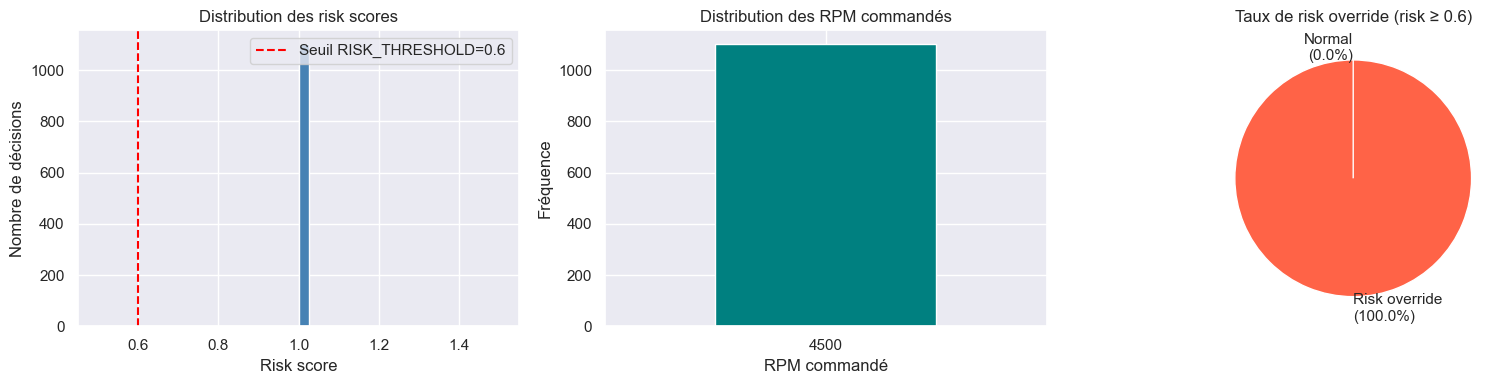

In [10]:
if not df_log.empty and "risk_score" in df_log.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Distribution risk_score
    ax = axes[0]
    df_log["risk_score"].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.axvline(0.6, color="red", ls="--", label="Seuil RISK_THRESHOLD=0.6")
    ax.set_xlabel("Risk score")
    ax.set_ylabel("Nombre de décisions")
    ax.set_title("Distribution des risk scores")
    ax.legend()

    # Distribution RPM commandé
    ax = axes[1]
    if "rpm_decided" in df_log.columns:
        df_log["rpm_decided"].value_counts().sort_index().plot(
            kind="bar", ax=ax, color="teal", edgecolor="white"
        )
        ax.set_xlabel("RPM commandé")
        ax.set_ylabel("Fréquence")
        ax.set_title("Distribution des RPM commandés")
        ax.tick_params(axis='x', rotation=0)

    # Taux de risk override
    ax = axes[2]
    if "risk_score" in df_log.columns and "rpm_decided" in df_log.columns:
        override = (df_log["risk_score"] >= 0.6).mean() * 100
        no_override = 100 - override
        ax.pie(
            [override, no_override],
            labels=[f"Risk override\n({override:.1f}%)", f"Normal\n({no_override:.1f}%)"],
            colors=["tomato", "steelblue"],
            startangle=90,
        )
        ax.set_title("Taux de risk override (risk ≥ 0.6)")

    plt.tight_layout()
    plt.show()

### 3.2 Évolution temporelle des décisions

Machine : srv-master-01 — 220 décisions


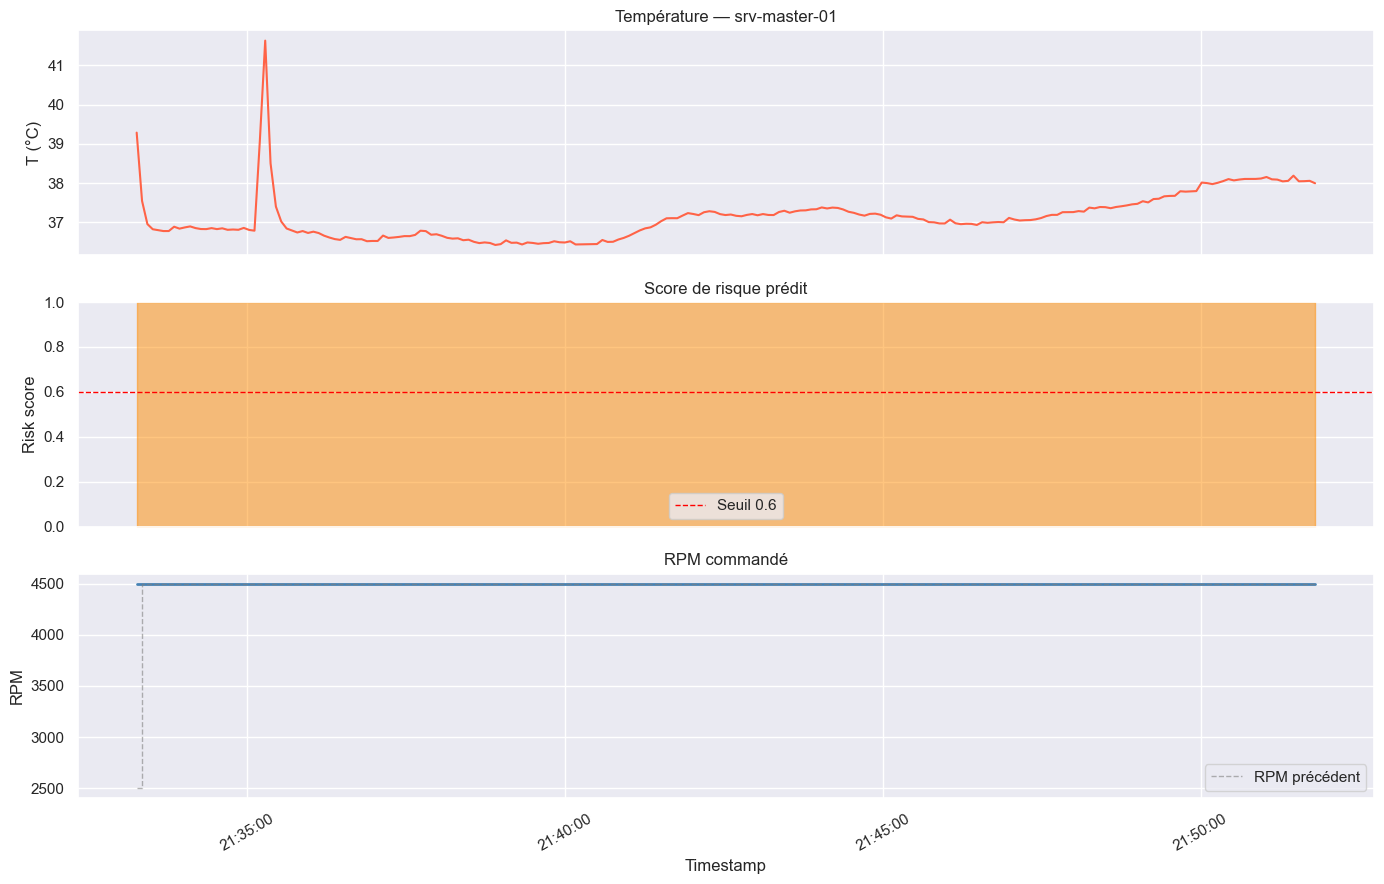

In [11]:
if not df_log.empty and "ts" in df_log.columns:
    # Sélectionner une machine
    machines = df_log["machine_id"].unique() if "machine_id" in df_log.columns else []
    machine = machines[0] if len(machines) > 0 else None

    if machine:
        df_m = df_log[df_log["machine_id"] == machine].copy().sort_values("ts")
        print(f"Machine : {machine} — {len(df_m)} décisions")

        fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

        # Température
        if "temperature_c" in df_m.columns:
            axes[0].plot(df_m["ts"], df_m["temperature_c"], color="tomato", lw=1.5)
            axes[0].set_ylabel("T (°C)")
            axes[0].set_title(f"Température — {machine}")

        # Risk score
        if "risk_score" in df_m.columns:
            axes[1].fill_between(df_m["ts"], df_m["risk_score"], alpha=0.5, color="darkorange")
            axes[1].axhline(0.6, color="red", ls="--", lw=1, label="Seuil 0.6")
            axes[1].set_ylabel("Risk score")
            axes[1].set_ylim(0, 1)
            axes[1].legend()
            axes[1].set_title("Score de risque prédit")

        # RPM commandé
        if "rpm_decided" in df_m.columns:
            axes[2].step(df_m["ts"], df_m["rpm_decided"], where="post", color="steelblue", lw=2)
            if "rpm_previous" in df_m.columns:
                axes[2].step(df_m["ts"], df_m["rpm_previous"], where="post", color="gray",
                            lw=1, ls="--", alpha=0.6, label="RPM précédent")
            axes[2].set_ylabel("RPM")
            axes[2].set_xlabel("Timestamp")
            axes[2].legend()
            axes[2].set_title("RPM commandé")
            axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
            plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

        plt.tight_layout()
        plt.show()

### 3.3 Vue multi-machines

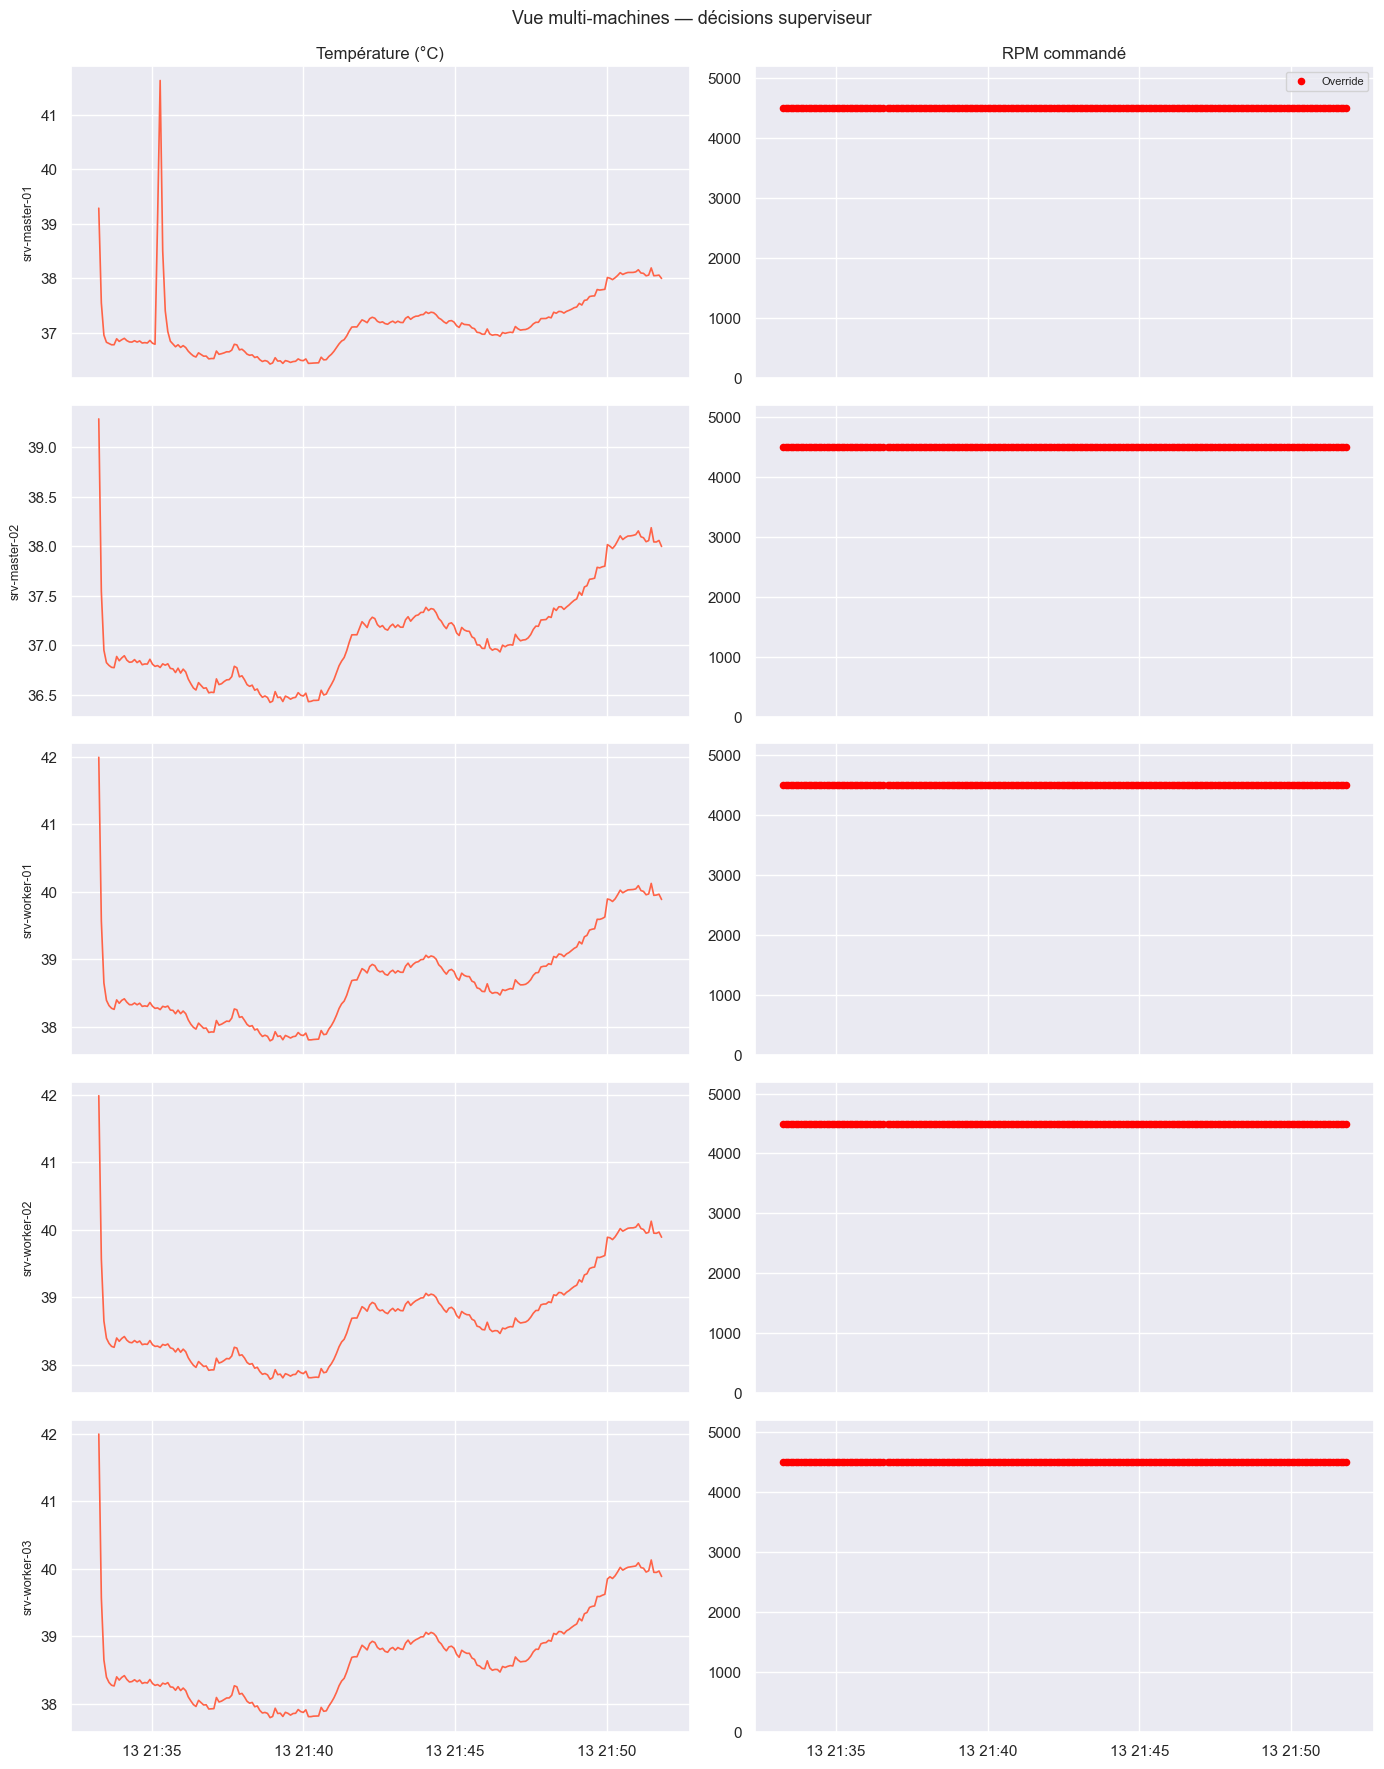

In [12]:
if not df_log.empty and "machine_id" in df_log.columns:
    machines = sorted(df_log["machine_id"].unique())
    n = len(machines)
    if n == 0:
        print("Pas de données.")
    else:
        fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n), sharex="col")
        if n == 1:
            axes = [axes]

        for i, machine in enumerate(machines):
            df_m = df_log[df_log["machine_id"] == machine].sort_values("ts")

            # Température
            ax = axes[i][0]
            if "temperature_c" in df_m.columns:
                ax.plot(df_m["ts"], df_m["temperature_c"], color="tomato", lw=1.2)
            ax.set_ylabel(machine, fontsize=9)
            if i == 0:
                ax.set_title("Température (°C)")

            # RPM
            ax = axes[i][1]
            if "rpm_decided" in df_m.columns:
                ax.step(df_m["ts"], df_m["rpm_decided"], where="post",
                        color="steelblue", lw=1.5)
                # Colorier les overrides
                if "risk_score" in df_m.columns:
                    override_mask = df_m["risk_score"] >= 0.6
                    overrides = df_m[override_mask]
                    if not overrides.empty:
                        ax.scatter(overrides["ts"], overrides["rpm_decided"],
                                   color="red", s=20, zorder=5, label="Override")
            ax.set_ylim(0, 5200)
            if i == 0:
                ax.set_title("RPM commandé")
                ax.legend(fontsize=8)

        plt.tight_layout()
        plt.suptitle("Vue multi-machines — décisions superviseur", y=1.01, fontsize=13)
        plt.show()

## 4. Impact de la vitesse de simulation sur les features

Démonstration que `OnlineFeatureBuffer` + MQTT donne des features correctes quelle que soit la vitesse, contrairement au polling REST.

In [13]:
# Simulation synthétique : comparer REST polling vs MQTT pour différentes vitesses
# On simule une montée en température à 1°C/s simulée

def simulate_features_polling(speed: float, poll_interval_s: float = 5.0, duration_sim_s: int = 120):
    """
    Simule un superviseur qui lit l'API REST toutes les poll_interval_s réelles.
    Retourne les temp_delta_5s calculés à chaque poll.
    """
    from supervisor.online_features import OnlineFeatureBuffer

    buf = OnlineFeatureBuffer()
    results = []

    # À speed x, le temps simulé avance de speed * poll_interval_s par poll
    sim_ticks_per_poll = int(speed * poll_interval_s)

    t_sim = 0
    base_temp = 60.0

    # Simuler un seul snapshot par poll (comme REST)
    while t_sim < duration_sim_s:
        temp = base_temp + t_sim * 0.3  # +0.3°C/s simulée
        snap = {
            "machine_id": "m0", "role": "worker", "status": "on",
            "temperature_c": temp, "sensor_temp_max": temp + 2,
            "sensor_temp_mean": temp + 1, "power_w": 300.0,
            "energy_kwh": 0.0, "load_estimated": 0.5,
            "fans": [{"idx": 0, "rpm": 2500}], "faults": [],
        }
        # REST : on ne met à jour qu'une fois par poll, peu importe les ticks manqués
        buf.update("m0", snap)
        feat = buf.get_features("m0")
        if feat is not None:
            results.append({"t_sim": t_sim, "temp": temp,
                             "delta_5s": feat["temp_delta_5s"],
                             "delta_30s": feat["temp_delta_30s"],
                             "method": f"REST speed={speed:.0f}x"})
        t_sim += sim_ticks_per_poll

    return pd.DataFrame(results)


def simulate_features_mqtt(speed: float, duration_sim_s: int = 120):
    """
    Simule un superviseur alimenté par MQTT (1 msg/s simulé).
    """
    from supervisor.online_features import OnlineFeatureBuffer

    buf = OnlineFeatureBuffer()
    results = []
    base_temp = 60.0

    for t_sim in range(duration_sim_s):
        temp = base_temp + t_sim * 0.3
        snap = {
            "machine_id": "m0", "role": "worker", "status": "on",
            "temperature_c": temp, "sensor_temp_max": temp + 2,
            "sensor_temp_mean": temp + 1, "power_w": 300.0,
            "energy_kwh": 0.0, "load_estimated": 0.5,
            "fans": [{"idx": 0, "rpm": 2500}], "faults": [],
        }
        buf.update("m0", snap)
        feat = buf.get_features("m0")
        if feat is not None:
            results.append({"t_sim": t_sim, "temp": temp,
                             "delta_5s": feat["temp_delta_5s"],
                             "delta_30s": feat["temp_delta_30s"],
                             "method": f"MQTT (référence)"})

    return pd.DataFrame(results)


# Valeurs théoriques attendues (montée à 0.3°C/s)
# temp_delta_5s  = 5 * 0.3 = 1.5°C
# temp_delta_30s = 30 * 0.3 = 9.0°C
TRUE_DELTA_5S  = 5  * 0.3
TRUE_DELTA_30S = 30 * 0.3
print(f"Valeurs théoriques attendues :")
print(f"  temp_delta_5s  = {TRUE_DELTA_5S:.1f}°C")
print(f"  temp_delta_30s = {TRUE_DELTA_30S:.1f}°C")

Valeurs théoriques attendues :
  temp_delta_5s  = 1.5°C
  temp_delta_30s = 9.0°C


In [14]:
# Comparer REST (speed=1x et speed=60x) vs MQTT
frames = []
frames.append(simulate_features_mqtt(speed=1))
for speed in [1, 10, 60]:
    frames.append(simulate_features_polling(speed=speed))

df_compare = pd.concat(frames, ignore_index=True)

# Résumé des erreurs par méthode
summary = df_compare.groupby("method").agg(
    delta_5s_mean=("delta_5s", "mean"),
    delta_30s_mean=("delta_30s", "mean"),
    n_polls=("t_sim", "count"),
).assign(
    erreur_5s=lambda d: (d["delta_5s_mean"] - TRUE_DELTA_5S).abs(),
    erreur_30s=lambda d: (d["delta_30s_mean"] - TRUE_DELTA_30S).abs(),
)
print("Précision des features selon la méthode d'alimentation :")
print(f"  Référence théorique : delta_5s={TRUE_DELTA_5S:.2f}°C  delta_30s={TRUE_DELTA_30S:.2f}°C")
display(summary.round(3))

Précision des features selon la méthode d'alimentation :
  Référence théorique : delta_5s=1.50°C  delta_30s=9.00°C


,delta_5s_mean,delta_30s_mean,n_polls,erreur_5s,erreur_30s
method,,,,,
MQTT (référence),1.438,6.75,120,0.062,2.25
REST speed=10x,0.000,0.00,3,1.500,9.00
REST speed=1x,5.938,0.00,24,4.438,9.00
REST speed=60x,0.000,0.00,1,1.500,9.00


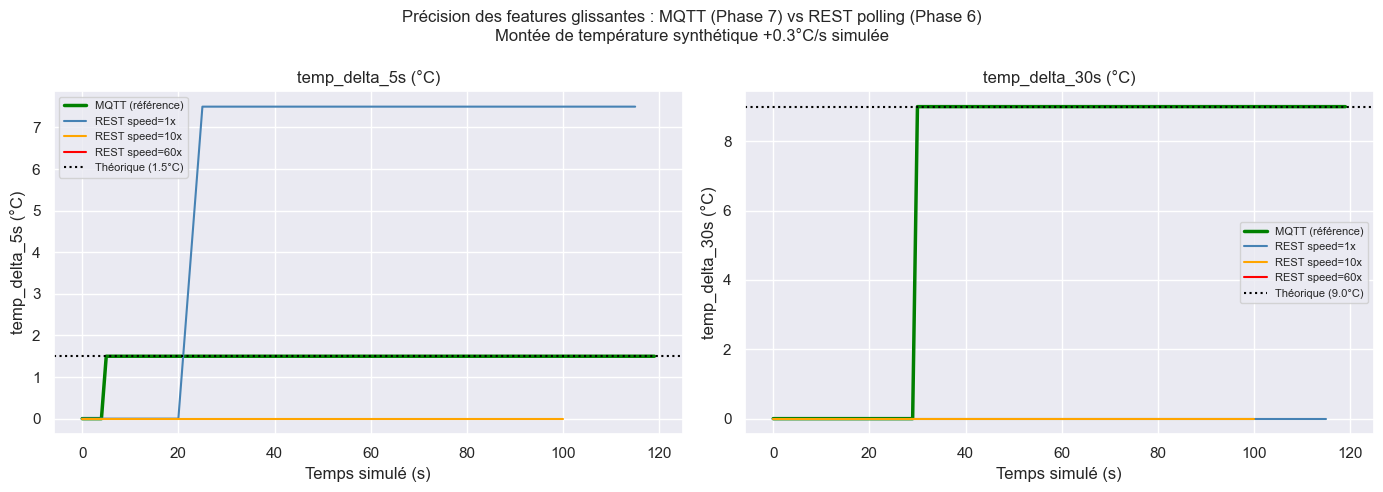

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = df_compare["method"].unique()
colors  = ["green", "steelblue", "orange", "red"]

for ax, feat, true_val, label in [
    (axes[0], "delta_5s",  TRUE_DELTA_5S,  "temp_delta_5s (°C)"),
    (axes[1], "delta_30s", TRUE_DELTA_30S, "temp_delta_30s (°C)"),
]:
    for method, color in zip(methods, colors):
        df_m = df_compare[df_compare["method"] == method]
        lw = 2.5 if "MQTT" in method else 1.5
        ax.plot(df_m["t_sim"], df_m[feat], label=method, lw=lw, color=color)
    ax.axhline(true_val, color="black", ls=":", lw=1.5, label=f"Théorique ({true_val:.1f}°C)")
    ax.set_xlabel("Temps simulé (s)")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle(
    "Précision des features glissantes : MQTT (Phase 7) vs REST polling (Phase 6)\n"
    "Montée de température synthétique +0.3°C/s simulée",
    fontsize=12
)
plt.tight_layout()
plt.show()

## 5. Test rapide du superviseur (dry-run)

Lance le superviseur pendant 30 secondes en mode dry-run (sans envoyer de commandes) et affiche les décisions.

In [16]:
# Vérifier que le simulateur est accessible avant de lancer le superviseur
try:
    r = httpx.get(f"{API_URL}/cluster/status", timeout=2.0)
    print("✅ Simulateur accessible — lancement du superviseur en dry-run (30s)...")
    SIMULATOR_OK = True
except Exception:
    print("❌ Simulateur non accessible — skipping superviseur dry-run.")
    print("   Lancez jumeaux-chauds et relancez cette cellule.")
    SIMULATOR_OK = False

✅ Simulateur accessible — lancement du superviseur en dry-run (30s)...


In [17]:
import subprocess
import tempfile

if SIMULATOR_OK:
    with tempfile.TemporaryDirectory() as tmpdir:
        cmd = [
            sys.executable, "-m", "supervisor.supervisor",
            "--mode", "ml",
            "--duration", "30",
            "--dry-run",
            "--api-url", API_URL,
            "--mqtt-host", MQTT_HOST,
            "--mqtt-port", str(MQTT_PORT),
            "--interval-ticks", "5",
            "--run-name", "notebook_dryrun",
        ]
        print(f"Commande : {' '.join(cmd)}")
        result = subprocess.run(
            cmd, capture_output=True, text=True, cwd=str(ROOT), timeout=60
        )
        print("--- STDOUT ---")
        print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
        if result.stderr:
            print("--- STDERR ---")
            print(result.stderr[-2000:] if len(result.stderr) > 2000 else result.stderr)
        print(f"\nCode de retour : {result.returncode}")

Commande : C:\Users\Tristan\.conda\envs\juste-des-ventilateurs\python.exe -m supervisor.supervisor --mode ml --duration 30 --dry-run --api-url http://localhost:8000 --mqtt-host localhost --mqtt-port 1883 --interval-ticks 5 --run-name notebook_dryrun
--- STDOUT ---

--- STDERR ---
PM 4500 (stable)
2026-06-13 23:52:13,629 [INFO] supervisor --   srv-worker-02         T= 39.8 degC  risk=1.00  hot30s=1.00  RPM 4500 (stable)
2026-06-13 23:52:13,630 [INFO] supervisor -- [t=16s speed=1x]  cluster -- 5 machines  T_max=39.8 C  risk_max=1.00
2026-06-13 23:52:18,644 [INFO] supervisor --   srv-worker-03         T= 39.8 degC  risk=1.00  hot30s=1.00  RPM 4500 (stable)
2026-06-13 23:52:18,654 [INFO] supervisor --   srv-master-01         T= 37.9 degC  risk=1.00  hot30s=1.00  RPM 4500 (stable)
2026-06-13 23:52:18,663 [INFO] supervisor --   srv-master-02         T= 37.9 degC  risk=1.00  hot30s=1.00  RPM 4500 (stable)
2026-06-13 23:52:18,672 [INFO] supervisor --   srv-worker-01         T= 39.8 degC  risk=

## 6. Synthèse Phase 7

Résumé des améliorations apportées par la Phase 7.

In [18]:
improvements = [
    {
        "Problème Phase 6": "Features glissantes toujours = 0.0",
        "Cause": "Snapshot unique, pas de mémoire temporelle",
        "Solution Phase 7": "OnlineFeatureBuffer (fenêtre 70 ticks)",
        "Impact": "Prédicteur voit les montées en température",
    },
    {
        "Problème Phase 6": "Fenêtres 5× trop larges à speed=1x",
        "Cause": "REST poll toutes les 5s réelles = 5s simulées",
        "Solution Phase 7": "MQTT : 1 msg/s simulé quelle que soit la vitesse",
        "Impact": "Features alignées avec l'entraînement",
    },
    {
        "Problème Phase 6": "Fenêtres 300× trop larges à speed=60x",
        "Cause": "REST poll = 300 secondes simulées par tick",
        "Solution Phase 7": "MQTT alimente à 60 msgs/s réel + sous-échantillonnage",
        "Impact": "Robustesse à toute vitesse de simulation",
    },
    {
        "Problème Phase 6": "Logs trop verbeux (12 lignes/min httpx)",
        "Cause": "Log INFO pour chaque GET HTTP",
        "Solution Phase 7": "httpx silencé, 1 ligne/cycle cluster + log machines si risk > seuil",
        "Impact": "Lisibilité opérationnelle",
    },
]

df_improvements = pd.DataFrame(improvements)
print("Améliorations Phase 7 — Superviseur robuste MQTT")
display(df_improvements.style.set_properties(**{"text-align": "left"}).hide(axis="index"))

Améliorations Phase 7 — Superviseur robuste MQTT


Problème Phase 6,Cause,Solution Phase 7,Impact
Features glissantes toujours = 0.0,"Snapshot unique, pas de mémoire temporelle",OnlineFeatureBuffer (fenêtre 70 ticks),Prédicteur voit les montées en température
Fenêtres 5× trop larges à speed=1x,REST poll toutes les 5s réelles = 5s simulées,MQTT : 1 msg/s simulé quelle que soit la vitesse,Features alignées avec l'entraînement
Fenêtres 300× trop larges à speed=60x,REST poll = 300 secondes simulées par tick,MQTT alimente à 60 msgs/s réel + sous-échantillonnage,Robustesse à toute vitesse de simulation
Logs trop verbeux (12 lignes/min httpx),Log INFO pour chaque GET HTTP,"httpx silencé, 1 ligne/cycle cluster + log machines si risk > seuil",Lisibilité opérationnelle


In [19]:
# Tableau de précision des features MQTT vs REST
print("\nPrécision des features selon la méthode (simulation synthétique +0.3°C/s) :")
print(f"Valeurs théoriques : delta_5s={TRUE_DELTA_5S:.2f}°C  delta_30s={TRUE_DELTA_30S:.2f}°C")
display(
    summary[["n_polls", "delta_5s_mean", "erreur_5s", "delta_30s_mean", "erreur_30s"]]
    .rename(columns={
        "n_polls": "N points",
        "delta_5s_mean": "delta_5s moyen",
        "erreur_5s": "Erreur delta_5s",
        "delta_30s_mean": "delta_30s moyen",
        "erreur_30s": "Erreur delta_30s",
    })
    .round(3)
    .style.background_gradient(subset=["Erreur delta_5s", "Erreur delta_30s"], cmap="RdYlGn_r")
)


Précision des features selon la méthode (simulation synthétique +0.3°C/s) :
Valeurs théoriques : delta_5s=1.50°C  delta_30s=9.00°C


,N points,delta_5s moyen,Erreur delta_5s,delta_30s moyen,Erreur delta_30s
method,,,,,
MQTT (référence),120,1.438000,0.062000,6.750000,2.250000
REST speed=10x,3,0.000000,1.500000,0.000000,9.000000
REST speed=1x,24,5.938000,4.438000,0.000000,9.000000
REST speed=60x,1,0.000000,1.500000,0.000000,9.000000


---

**Conclusions Phase 7 :**
- L'alimentation par MQTT (`MqttTelemetryConsumer` + `OnlineFeatureBuffer`) corrige fondamentalement la dérive des features temporelles présente en Phase 6.
- Les features `temp_delta_5s/15s/30s` sont désormais calculées sur les bonnes fenêtres simulées, alignées avec les données d'entraînement.
- Le sous-échantillonnage (`decision_interval_ticks`) garantit que le rythme des commandes fans reste stable quelle que soit la vitesse de simulation.
- Le fallback REST assure la continuité de service si le broker MQTT est indisponible.